In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.anova import AnovaRM


RESULTS_DIR = Path("../results")
N_SAMPLES = 64
SEEDS = range(5)        
BATCH_SIZES = [1, 2, 4, 8]
VARIANTS = range(2)

# time

In [2]:
records = []
for seed in SEEDS:
    for b in BATCH_SIZES:
        for v in VARIANTS:
            subdir = RESULTS_DIR / f"cache2_n{N_SAMPLES}_s{seed}_b{b}_v{v}"
            csv_path = subdir / "run_times.csv"
            if not csv_path.exists():
                continue
            df_sbv = pd.read_csv(csv_path)
            df_sbv["seed"] = seed
            df_sbv["batch_size"] = b
            df_sbv["variant"] = v
            records.append(df_sbv)
combined = pd.concat(records, ignore_index=True)
df_time = combined[['script', 'predict_time_s', 'total_time_s', 'seed', 'batch_size', 'variant']]


In [3]:
df = df_time.copy()
df['script_short'] = df['script'].str.split('_', n=1).str[1]

df_wide = df.pivot(
    index=['seed', 'batch_size', 'variant'],
    columns='script_short',
    values=['predict_time_s', 'total_time_s'],
)

df_wide.columns = [
    f"{script}_{metric}" 
    for metric, script in df_wide.columns
]

df_wide = df_wide.reset_index()
df_wide['predict_time_s'] = df_wide['structure_predict_time_s']+df_wide['affinity_predict_time_s']
df_wide['total_time_s'] = df_wide['structure_total_time_s']+df_wide['affinity_total_time_s']


In [4]:
# base = df_wide[df_wide['batch_size'] == 1].set_index(['seed', 'variant'])

# df = df_wide.merge(
#     base[['affinity_predict_time_s', 'structure_predict_time_s', 
#           'affinity_total_time_s', 'structure_total_time_s']],
#     on=['seed', 'variant'], suffixes=('', '_base')
# )

# for col in ['affinity_predict_time_s', 'structure_predict_time_s', 
#             'affinity_total_time_s', 'structure_total_time_s']:
#     df[f'{col}_improvement_%'] = (df[f'{col}_base'] - df[col]) / df[f'{col}_base'] * 100

# result = df[
#     ['seed', 'variant', 'batch_size'] +
#     [f'{col}_improvement_%' for col in [
#         'affinity_predict_time_s', 'structure_predict_time_s', 
#         'affinity_total_time_s', 'structure_total_time_s'
#     ]]
# ].reset_index(drop=True)

# result = result.sort_values(by=['seed', 'variant', 'batch_size'])

base = df_wide[df_wide['batch_size'] == 1].set_index(['seed', 'variant'])

df = df_wide.merge(
    base[['predict_time_s', 'total_time_s']],
    on=['seed', 'variant'], suffixes=('', '_base')
)

for col in ['predict_time_s', 'total_time_s']:
    df[f'{col}_improvement_%'] = (df[f'{col}_base'] - df[col]) / df[f'{col}_base'] * 100

result = df[
    ['seed', 'variant', 'batch_size'] +
    [f'{col}_improvement_%' for col in [
        'predict_time_s', 'total_time_s'
    ]]
].reset_index(drop=True)

result = result.sort_values(by=['seed', 'variant', 'batch_size'])


   batch_size  avg_predict_time_s_improvement_%
0           1                          0.000000
1           2                         13.053985
2           4                         18.107116
3           8                         19.178777


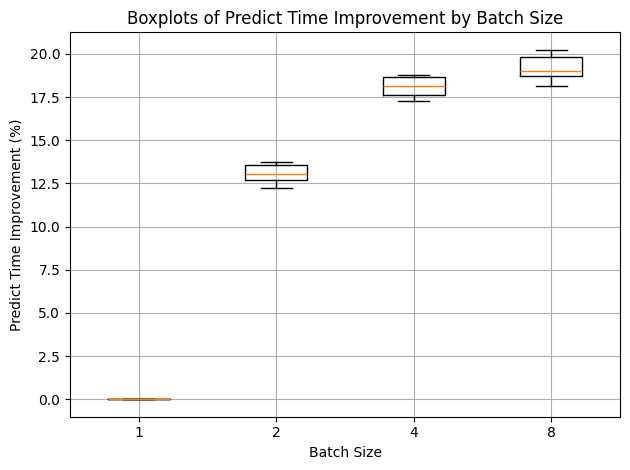

In [5]:
df_avg = (
    result
    .groupby('batch_size')['predict_time_s_improvement_%']
    .mean()
    .reset_index(name='avg_predict_time_s_improvement_%')
)

print(df_avg)

batch_sizes = sorted(result['batch_size'].unique())

data = [
    result.loc[result['batch_size'] == bs, 'predict_time_s_improvement_%'].values
    for bs in batch_sizes
]

plt.figure()
plt.boxplot(data, tick_labels=batch_sizes)  # <- here
plt.xlabel('Batch Size')
plt.ylabel('Predict Time Improvement (%)')
plt.title('Boxplots of Predict Time Improvement by Batch Size')
plt.grid(True)
plt.tight_layout()
plt.show()


# affinity

In [6]:
records = []
for seed in SEEDS:
    for b in BATCH_SIZES:
        for v in VARIANTS:
            for n in range(N_SAMPLES):
                subdir = RESULTS_DIR / f"cache2_n{N_SAMPLES}_s{seed}_b{b}_v{v}/predictions/lig_{n}"
                jsn_path = subdir / f"affinity_lig_{n}.json"
                if jsn_path.exists():
                    with jsn_path.open("r", encoding="utf-8") as f:
                        data = json.load(f)
                    records.append({
                        "seed": seed,
                        "batch_size": b,
                        "variant": v,
                        "ligand": n,
                        "affinity_pred_value": data.get("affinity_pred_value")
                    })

df = pd.DataFrame(records)
df['b_v'] = df.apply(lambda x: 'b'+str(int(x.batch_size))+'_v'+str(int(x.variant)), axis=1)
df['s_b_v'] = df.apply(lambda x: 's'+str(int(x.seed))+'_b'+str(int(x.batch_size))+'_v'+str(int(x.variant)), axis=1)
df['s_l'] = df.apply(lambda x: 's'+str(int(x.seed))+'_l'+str(int(x.ligand)), axis=1)
df['s_l_v'] = df.apply(lambda x: 's'+str(int(x.seed))+'_l'+str(int(x.ligand))+'_v'+str(int(x.variant)), axis=1)


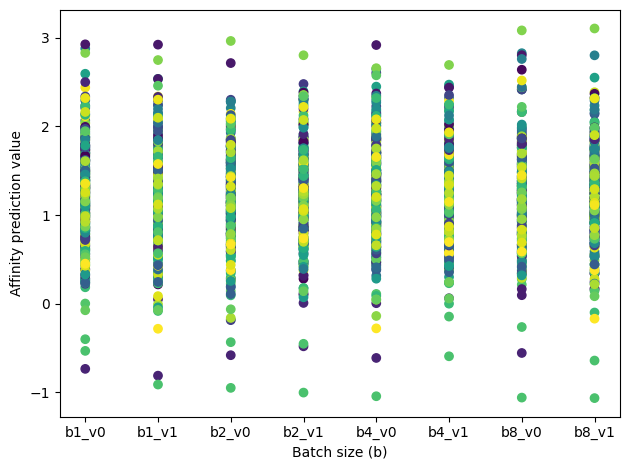

In [7]:
plt.figure()
plt.scatter(df['b_v'], df['affinity_pred_value'], c=df["ligand"])
plt.xlabel('Batch size (b)')
plt.ylabel('Affinity prediction value')
plt.tight_layout()
plt.show()


In [8]:
pivot = df.pivot_table(
    index=['seed', 'batch_size', 'ligand'],
    columns='variant',
    values='affinity_pred_value'
)

pivot['variance_v0_v1'] = pivot.var(axis=1)
result = pivot.reset_index()[['seed', 'batch_size', 'ligand', 'variance_v0_v1']]

result = result[result.batch_size==1]
vars1 = []
for s in SEEDS:
    result_s = result[result.seed==s]
    vars1.append(result_s.variance_v0_v1.mean())

result = (
    df
    .groupby(['seed', 'ligand'])['affinity_pred_value']
    .var(ddof=1)
    .reset_index(name='variance_all')
)

vars2 = []
for s in SEEDS:
    result_s = result[result.seed==s]
    vars2.append(result_s.variance_all.mean())

vars1 = np.array(vars1)
vars2 = np.array(vars2)

# Параметрический парный t‑тест (тест Стьюдента для связанных выборок)
t_stat, p_value = stats.ttest_rel(vars1, vars2)
print(f"Paired t-test:\n  t-statistic = {t_stat:.4f}\n  p-value     = {p_value:.4f}")

# Для непараметрической проверки можно использовать тест Уилкоксона:
w_stat, p_wilcox = stats.wilcoxon(vars1, vars2)
print(f"Wilcoxon signed‐rank test:\n  W = {w_stat:.4f}\n  p-value = {p_wilcox:.4f}")


Paired t-test:
  t-statistic = -1.6285
  p-value     = 0.1787
Wilcoxon signed‐rank test:
  W = 2.0000
  p-value = 0.1875


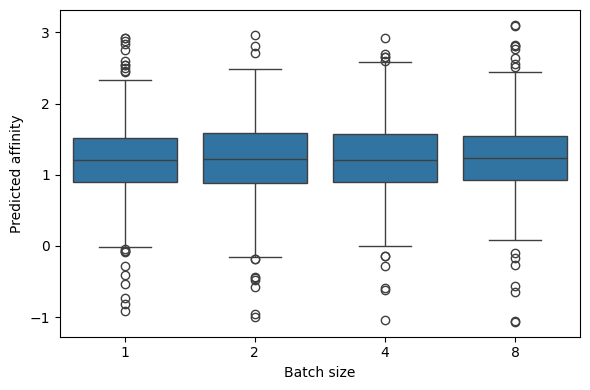

                  Anova
           F Value Num DF   Den DF  Pr > F
------------------------------------------
batch_size  1.2918 3.0000 1887.0000 0.2756

Friedman test: χ² = 0.804, p = 8.486e-01


In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='batch_size', y='affinity_pred_value', data=df)
plt.xlabel('Batch size')
plt.ylabel('Predicted affinity')
plt.tight_layout()
plt.show()

aovrm = AnovaRM(df, depvar='affinity_pred_value', subject='s_l_v', within=['batch_size'])
res = aovrm.fit()
print(res)

groups = [df[df['batch_size']==b]['affinity_pred_value'].values
          for b in sorted(df['batch_size'].unique())]
chi2, p = stats.friedmanchisquare(*groups)
print(f"Friedman test: χ² = {chi2:.3f}, p = {p:.3e}")
